# Factor Importance Analysis
Analyses XGBoost ensemble feature importance from the A/B/C harness retrain artifacts.  
Set `HALF_LIFE` in the setup cell below to switch between runs: `"hl60"`, `"hl120"`, or `"hlinf"`.

In [81]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

ROOT   = Path("../data/backtest/xgboost_ab")
IMP_DIR = ROOT / "feature_importance"
MDL_DIR = ROOT / "models"

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

## 1 · Load & Resolve Feature Names
XGBoost stores features as `f0`, `f1`, … internally.  
We load each year's pkl to map `f{i}` → the actual JKP column name.

In [82]:
def _resolve_features(df_year: pd.DataFrame, feature_names: list[str]) -> pd.DataFrame:
    """Replace 'f{i}' labels with actual column names using that year's cur_cols."""
    def _map(f):
        try:
            idx = int(f[1:])
            return feature_names[idx] if idx < len(feature_names) else f
        except (ValueError, IndexError):
            return f
    df_year = df_year.copy()
    df_year["feature"] = df_year["feature"].map(_map)
    return df_year


frames = []
imp_files  = sorted(IMP_DIR.glob("importance_*.csv"))
model_files = {int(p.stem.split("_")[1]): p for p in MDL_DIR.glob("ensemble_*.pkl")}

for csv_path in imp_files:
    year = int(csv_path.stem.split("_")[1])
    df   = pd.read_csv(csv_path)
    if year in model_files:
        with open(model_files[year], "rb") as fh:
            artifact = pickle.load(fh)
        df = _resolve_features(df, artifact["feature_names"])
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)
years = sorted(raw["year"].unique())
print(f"Loaded {len(frames)} years ({years[0]}–{years[-1]}), "
      f"{raw['feature'].nunique():,} unique features")
raw.head()

Loaded 40 years (1986–2025), 345 unique features


,year,feature,gain,weight,cover,gain_norm
0,1986,ebit_me,18.110441,8.666667,86024.721354,0.036021
1,1986,ebitda_me,17.132281,2.333333,64761.287760,0.034076
2,1986,ebitda_mev,12.573525,1.333333,67270.988281,0.025008
3,1986,ni_me,12.374603,10.666667,57788.753906,0.024613
4,1986,ebit_mev,12.355430,3.666667,67952.769531,0.024575


## 2 · Number of Factors Used Over Time
How many factors does the model actually split on each year?

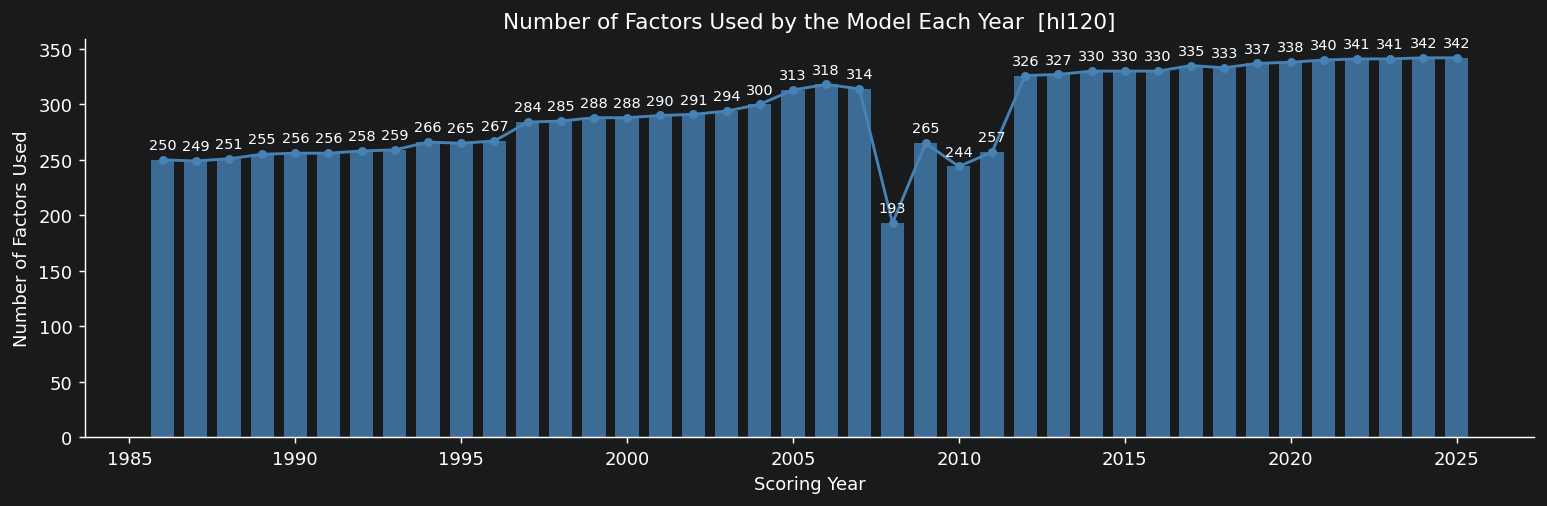

year
1986    250
1987    249
1988    251
1989    255
1990    256
1991    256
1992    258
1993    259
1994    266
1995    265
1996    267
1997    284
1998    285
1999    288
2000    288
2001    290
2002    291
2003    294
2004    300
2005    313
2006    318
2007    314
2008    193
2009    265
2010    244
2011    257
2012    326
2013    327
2014    330
2015    330
2016    330
2017    335
2018    333
2019    337
2020    338
2021    340
2022    341
2023    341
2024    342
2025    342


In [83]:
n_factors = raw.groupby("year")["feature"].nunique()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(n_factors.index, n_factors.values, color="steelblue", alpha=0.8, width=0.7)
ax.plot(n_factors.index, n_factors.values, color="steelblue", linewidth=1.6, marker="o", markersize=4)
for yr, val in n_factors.items():
    ax.annotate(str(val), (yr, val), textcoords="offset points",
                xytext=(0, 6), ha="center", fontsize=8)
ax.set_xlabel("Scoring Year")
ax.set_ylabel("Number of Factors Used")
ax.set_title(f"Number of Factors Used by the Model Each Year  [{HALF_LIFE}]")
plt.tight_layout()
plt.savefig(IMP_DIR / "factor_count_over_time.png", bbox_inches="tight")
plt.show()

print(n_factors.rename("n_factors").to_string())

## 2 · Top Factors — Full Sample (Mean Gain)
Gain measures the average improvement in loss brought by a feature each time it is used as a split — the most informative single importance metric.

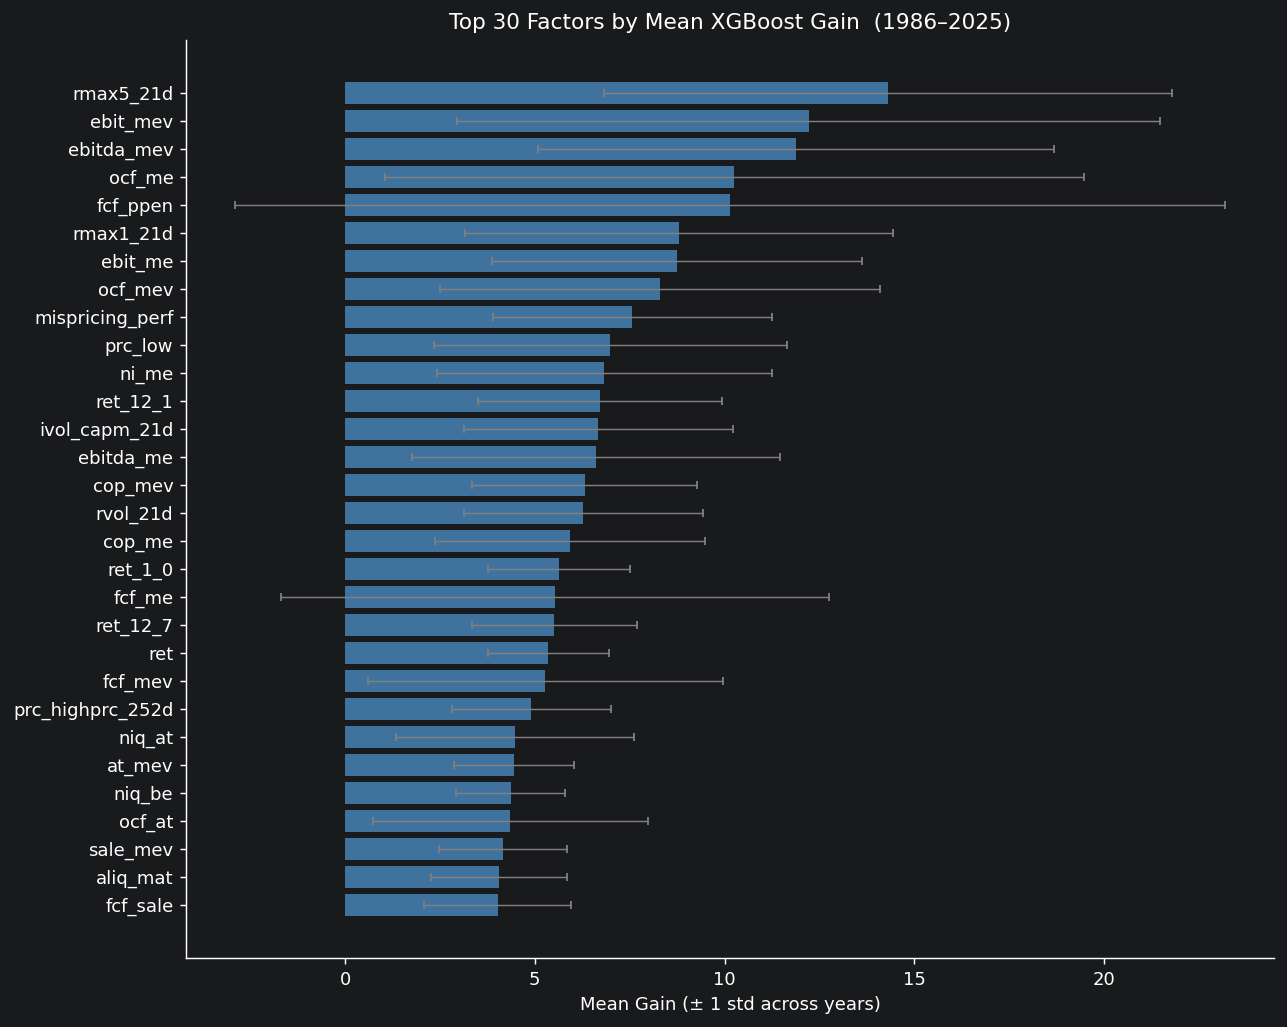


Top 20 factors:


,feature,gain_mean,gain_std,gain_norm_mean,weight_mean,cover_mean,pct_years_active
0,rmax5_21d,14.300759,7.488213,0.016530,51.471264,289811.458962,0.725
1,ebit_mev,12.220834,9.259628,0.016967,8.950000,186361.960449,1.000
2,ebitda_mev,11.878275,6.800768,0.015108,9.608333,178975.079558,1.000
3,ocf_me,10.253549,9.210219,0.012471,9.000000,199404.444084,1.000
4,fcf_ppen,10.144097,13.032752,0.012658,10.241667,154225.660482,1.000
5,rmax1_21d,8.799600,5.633950,0.010119,13.494253,148098.976742,0.725
6,ebit_me,8.743470,4.869535,0.012649,18.025000,194482.126497,1.000
7,ocf_mev,8.294988,5.799081,0.010414,8.108333,135918.853442,1.000
8,mispricing_perf,7.564133,3.678966,0.009808,19.025000,168390.608382,1.000
9,prc_low,6.986389,4.649345,0.010625,18.241667,182193.472282,1.000


In [84]:
TOP_N = 30

summary = (
    raw.groupby("feature")[["gain", "gain_norm", "weight", "cover"]]
    .agg(["mean", "std", "count"])
)
summary.columns = ["_".join(c) for c in summary.columns]
summary = summary.sort_values("gain_mean", ascending=False).reset_index()
summary["pct_years_active"] = summary["gain_count"] / len(years)

top = summary.head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top["feature"][::-1], top["gain_mean"][::-1], color="steelblue", alpha=0.85)
ax.errorbar(
    top["gain_mean"][::-1], range(TOP_N),
    xerr=top["gain_std"][::-1], fmt="none", color="grey", linewidth=0.8, capsize=2
)
ax.set_xlabel("Mean Gain (± 1 std across years)")
ax.set_title(f"Top {TOP_N} Factors by Mean XGBoost Gain  ({years[0]}–{years[-1]})")
plt.tight_layout()
plt.savefig(IMP_DIR / "top_factors_bar.png", bbox_inches="tight")
plt.show()

print("\nTop 20 factors:")
display(summary[["feature", "gain_mean", "gain_std", "gain_norm_mean",
                  "weight_mean", "cover_mean", "pct_years_active"]].head(20))

## 3 · Importance Heatmap Over Time
Columns = years, rows = top factors, colour = gain_norm (normalised to sum-to-1 each year).

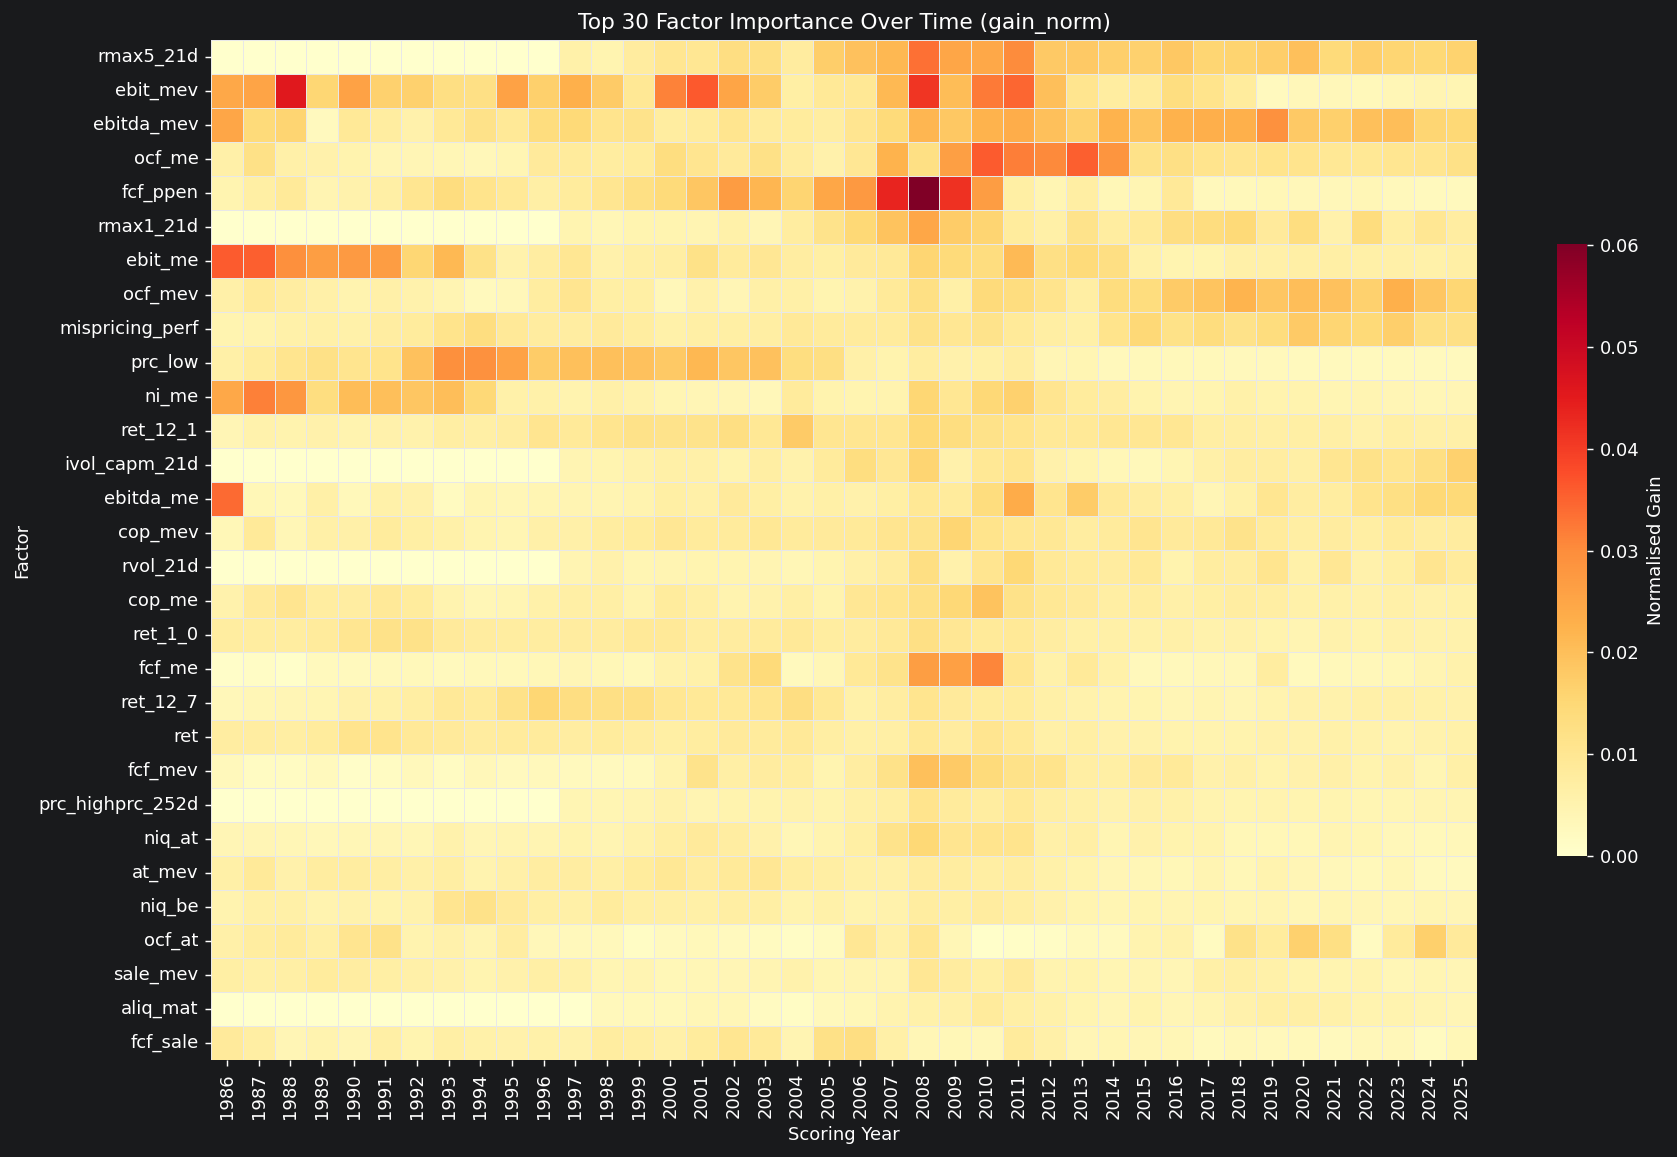

In [85]:
HMAP_N = 30
top_features = summary.head(HMAP_N)["feature"].tolist()

pivot = (
    raw[raw["feature"].isin(top_features)]
    .pivot_table(index="feature", columns="year", values="gain_norm", aggfunc="mean")
    .reindex(index=top_features)          # keep top-by-mean order
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    pivot, ax=ax, cmap="YlOrRd",
    linewidths=0.3, linecolor="#e8e8e8",
    cbar_kws={"label": "Normalised Gain", "shrink": 0.6},
    xticklabels=True, yticklabels=True
)
ax.set_title(f"Top {HMAP_N} Factor Importance Over Time (gain_norm)")
ax.set_xlabel("Scoring Year"); ax.set_ylabel("Factor")
plt.tight_layout()
plt.savefig(IMP_DIR / "importance_heatmap.png", bbox_inches="tight")
plt.show()

## 4 · Top Factor Trends Over Time
How has each top factor's relative importance changed year by year?

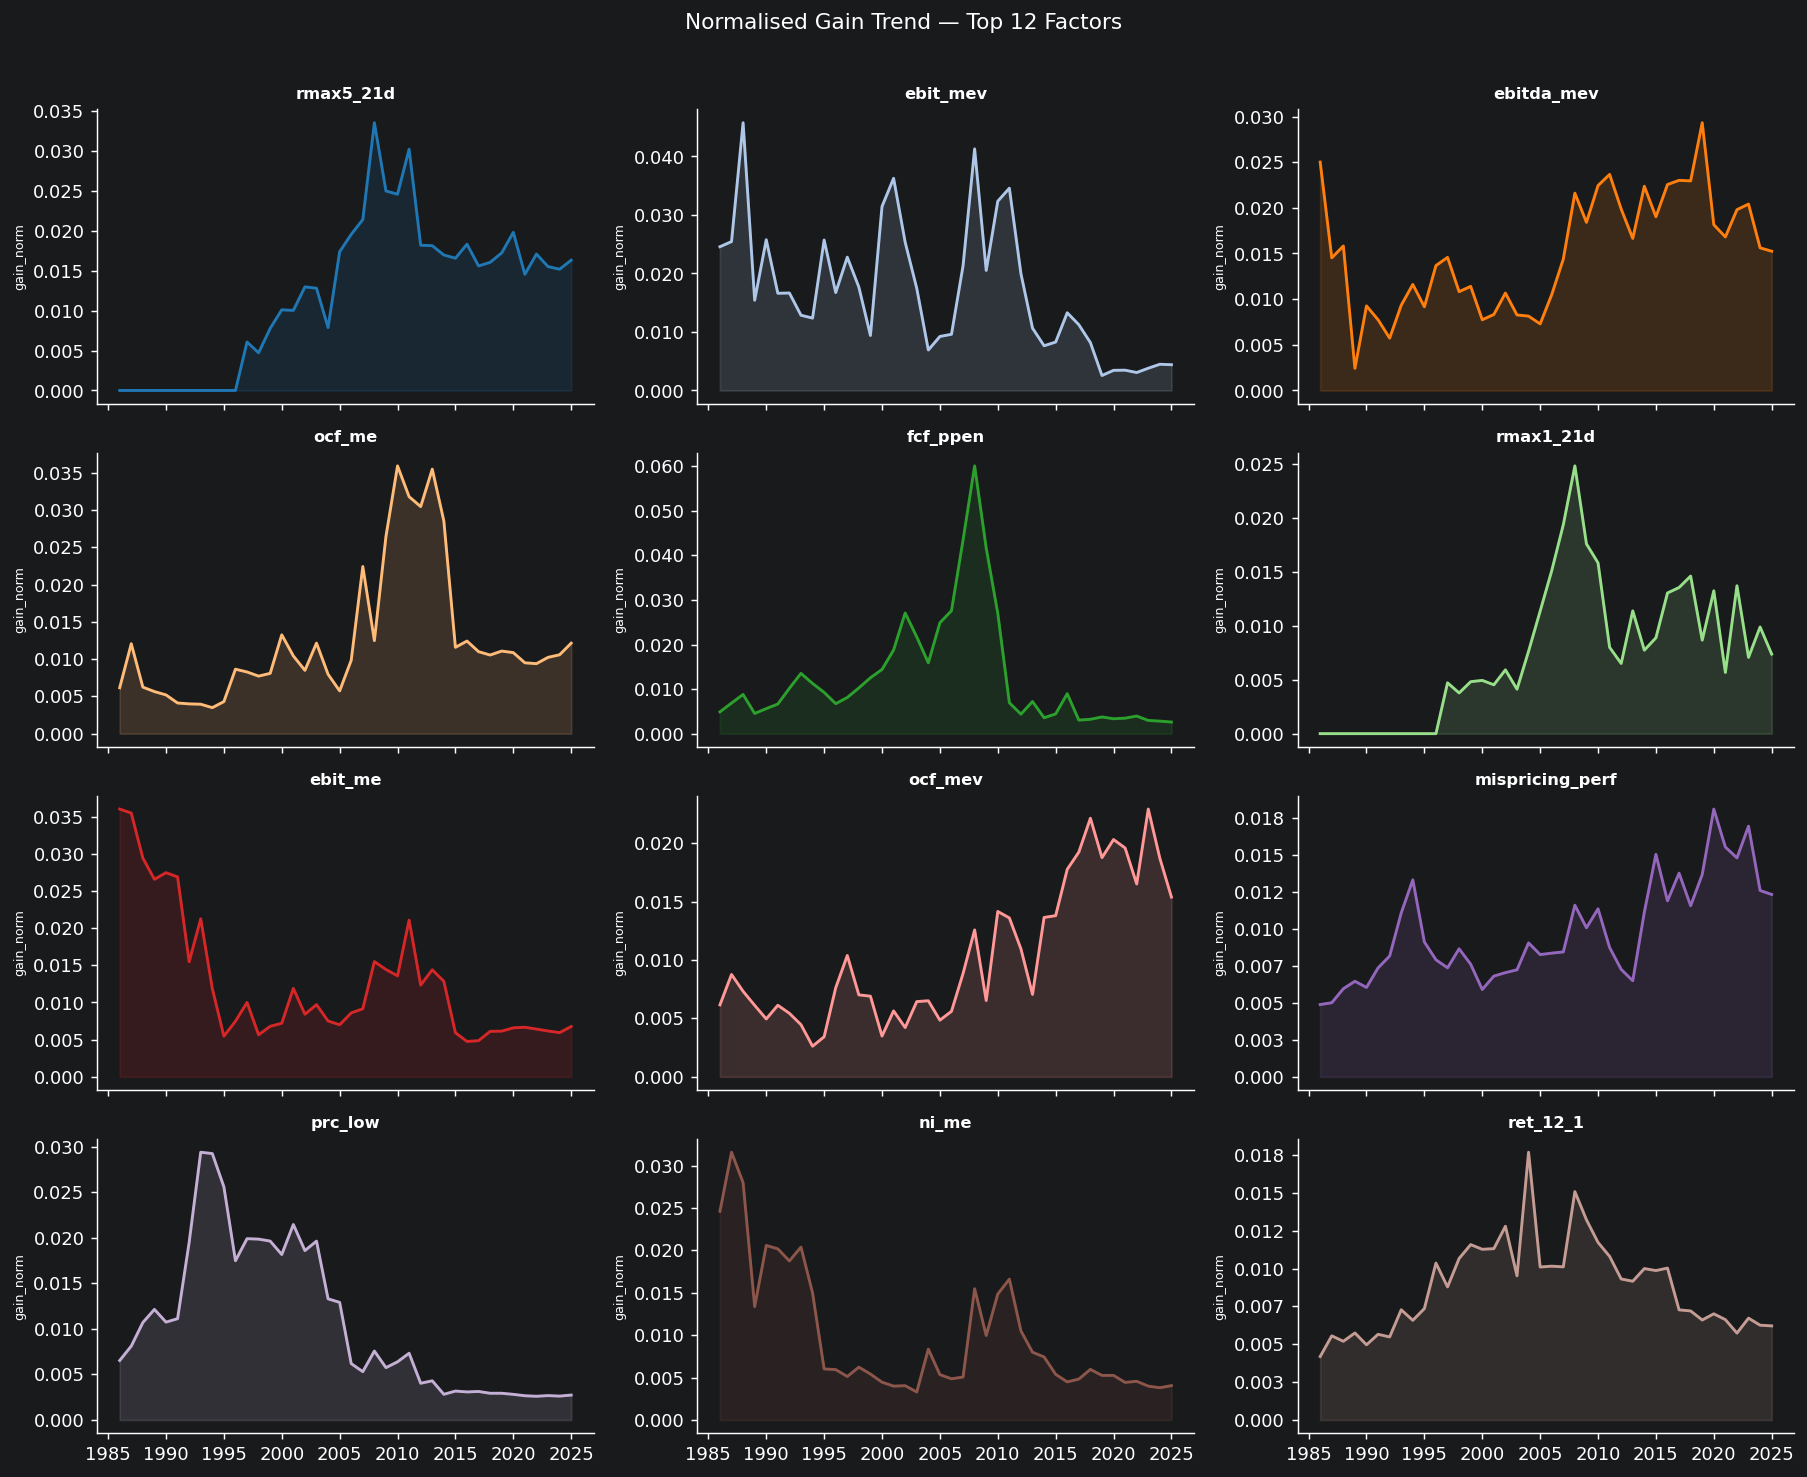

In [86]:
TREND_N = 12
trend_features = summary.head(TREND_N)["feature"].tolist()

trend_df = (
    raw[raw["feature"].isin(trend_features)]
    .pivot_table(index="year", columns="feature", values="gain_norm", aggfunc="mean")
    .fillna(0)
)

n_cols = 3
n_rows = int(np.ceil(TREND_N / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2.8), sharex=True)
axes = axes.flatten()

palette = plt.cm.tab20.colors
for i, feat in enumerate(trend_features):
    ax = axes[i]
    if feat in trend_df.columns:
        ax.plot(trend_df.index, trend_df[feat], color=palette[i], linewidth=1.6)
        ax.fill_between(trend_df.index, trend_df[feat], alpha=0.15, color=palette[i])
    ax.set_title(feat, fontsize=9, fontweight="bold")
    ax.set_ylabel("gain_norm", fontsize=7)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.3f"))

for j in range(TREND_N, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Normalised Gain Trend — Top {TREND_N} Factors", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(IMP_DIR / "factor_trends.png", bbox_inches="tight")
plt.show()

## 5 · Rank Stability
For each factor we compute its **gain rank** each year (1 = highest importance) and report the mean rank and rank standard deviation across years.  
Low mean rank + low std → consistently dominant factor.

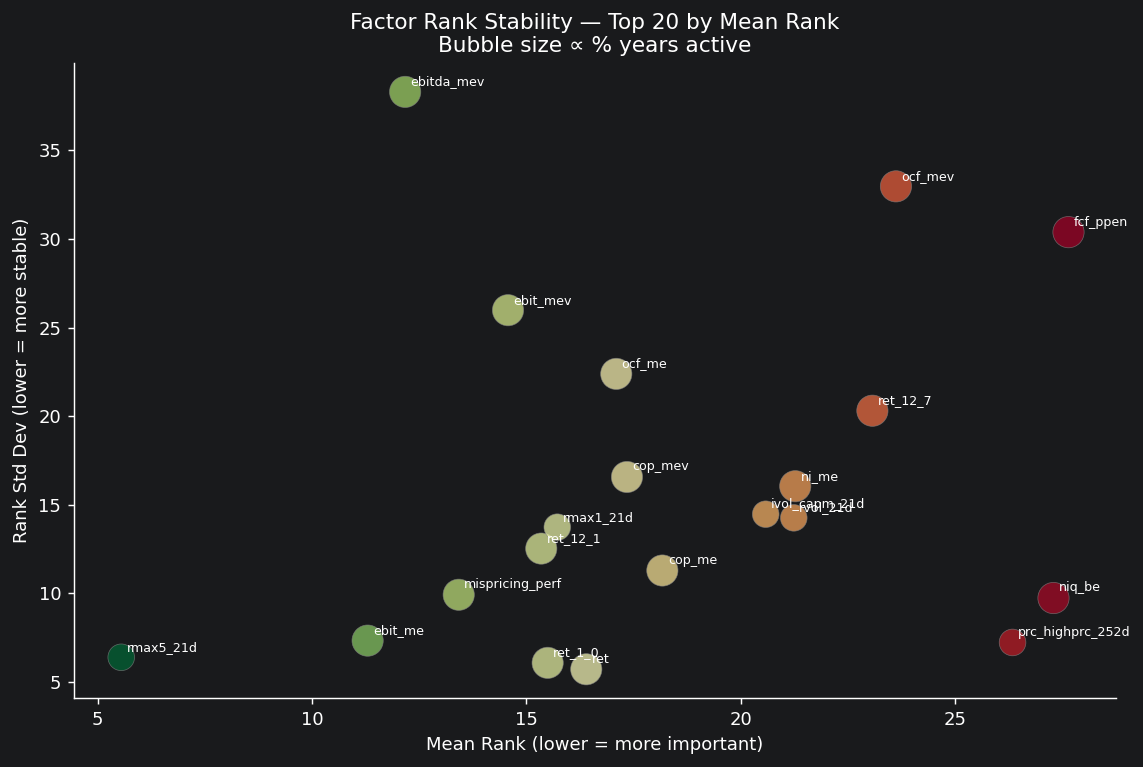


Top 20 by mean rank:


,feature,mean_rank,std_rank,years_active,pct_active
0,rmax5_21d,5.551724,6.395234,29,0.725
1,ebit_me,11.300000,7.335198,40,1.000
2,ebitda_mev,12.175000,38.295000,40,1.000
3,mispricing_perf,13.425000,9.922488,40,1.000
4,ebit_mev,14.575000,25.979171,40,1.000
5,ret_12_1,15.350000,12.528020,40,1.000
6,ret_1_0,15.500000,6.080654,40,1.000
7,rmax1_21d,15.724138,13.737063,29,0.725
8,ret,16.400000,5.719064,40,1.000
9,ocf_me,17.100000,22.384518,40,1.000


In [87]:
RANK_TOP = 20

rank_df = (
    raw.copy()
    .assign(rank=lambda d: d.groupby("year")["gain"].rank(ascending=False))
    .groupby("feature")["rank"]
    .agg(mean_rank="mean", std_rank="std", years_active="count")
    .dropna()
    .assign(pct_active=lambda d: d["years_active"] / len(years))
    .sort_values("mean_rank")
    .reset_index()
)

top_rank = rank_df.head(RANK_TOP)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(top_rank["mean_rank"], top_rank["std_rank"],
           s=top_rank["pct_active"] * 300, alpha=0.7,
           c=top_rank["mean_rank"], cmap="RdYlGn_r", edgecolors="grey", linewidth=0.4)
for _, row in top_rank.iterrows():
    ax.annotate(row["feature"], (row["mean_rank"], row["std_rank"]),
                fontsize=7, ha="left", va="bottom",
                xytext=(3, 2), textcoords="offset points")
ax.set_xlabel("Mean Rank (lower = more important)")
ax.set_ylabel("Rank Std Dev (lower = more stable)")
ax.set_title(f"Factor Rank Stability — Top {RANK_TOP} by Mean Rank\n"
             "Bubble size ∝ % years active")
plt.tight_layout()
plt.savefig(IMP_DIR / "rank_stability.png", bbox_inches="tight")
plt.show()

print("\nTop 20 by mean rank:")
display(rank_df.head(20))

## 6 · Year-over-Year Importance Correlation
Spearman correlation of the full gain vector between consecutive years.  
High correlation → the model's factor view is stable; a sudden drop signals a regime shift.

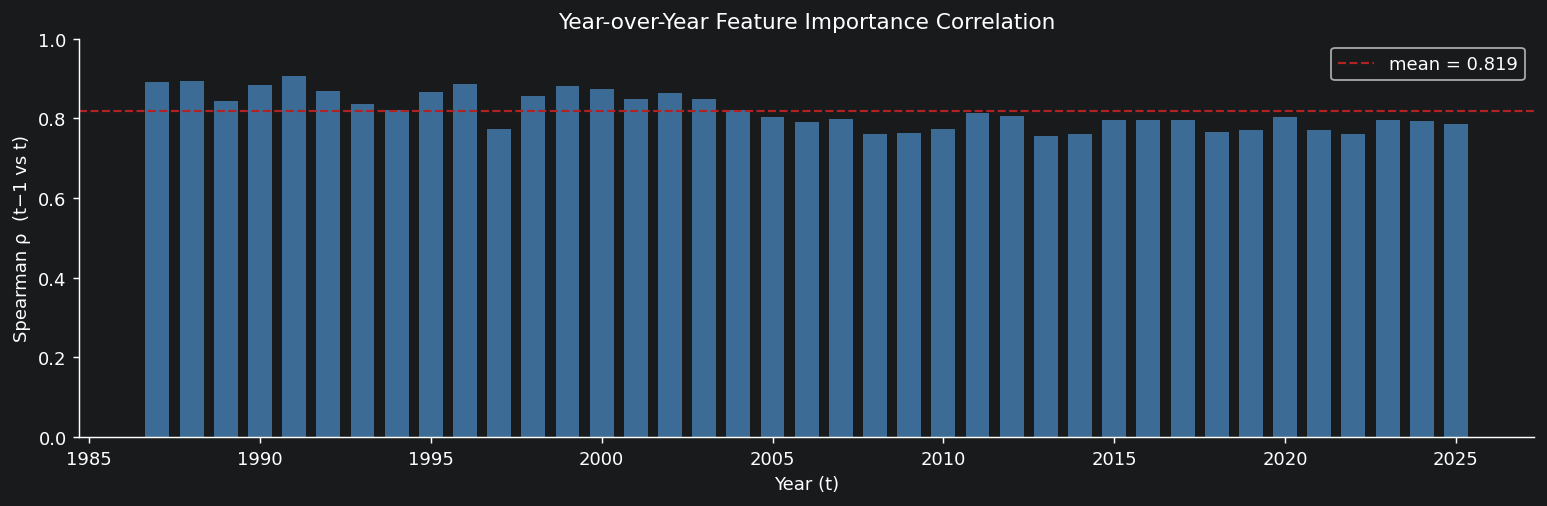

Mean YoY Spearman ρ : 0.8189
Min  YoY Spearman ρ : 2012→2013  = 0.7553


In [88]:
all_features = raw["feature"].unique()
year_vecs = {}
for yr in years:
    sub = raw[raw["year"] == yr].set_index("feature")["gain"]
    year_vecs[yr] = sub.reindex(all_features).fillna(0)

yoy_corr = []
for i in range(len(years) - 1):
    y1, y2 = years[i], years[i + 1]
    rho, _ = spearmanr(year_vecs[y1], year_vecs[y2])
    yoy_corr.append({"year_pair": f"{y1}→{y2}", "year": y2, "spearman_rho": rho})

corr_df = pd.DataFrame(yoy_corr)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(corr_df["year"], corr_df["spearman_rho"], color="steelblue", alpha=0.8, width=0.7)
ax.axhline(corr_df["spearman_rho"].mean(), color="firebrick", linestyle="--",
           linewidth=1.2, label=f"mean = {corr_df['spearman_rho'].mean():.3f}")
ax.set_xlabel("Year (t)")
ax.set_ylabel("Spearman ρ  (t−1 vs t)")
ax.set_title("Year-over-Year Feature Importance Correlation")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(IMP_DIR / "yoy_correlation.png", bbox_inches="tight")
plt.show()

print(f"Mean YoY Spearman ρ : {corr_df['spearman_rho'].mean():.4f}")
print(f"Min  YoY Spearman ρ : {corr_df.loc[corr_df['spearman_rho'].idxmin(), 'year_pair']}  "
      f"= {corr_df['spearman_rho'].min():.4f}")

## 7 · Factor Category Breakdown
Rough mapping of JKP column prefixes to factor families.  
Adjust `CATEGORY_MAP` if you want finer groupings.

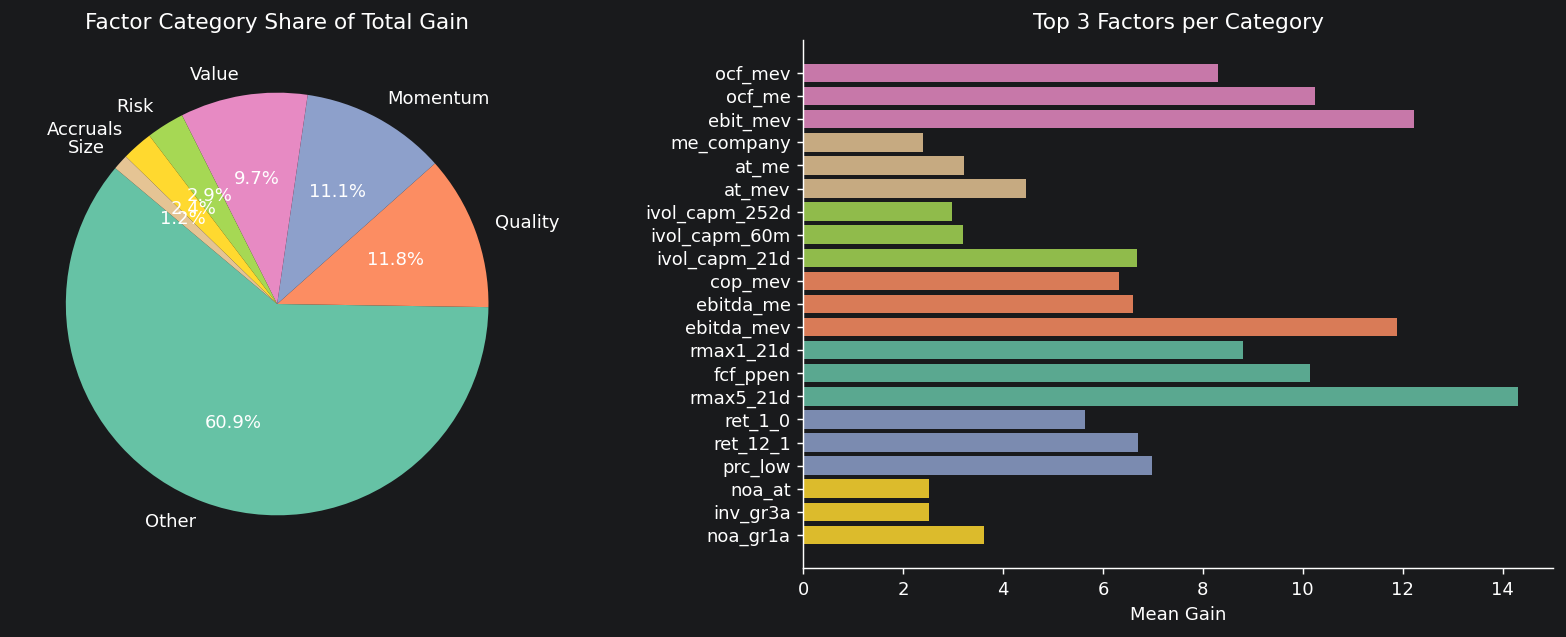


Gain by category:


,total_mean_gain
category,
Other,518.593710
Quality,100.681929
Momentum,94.647554
Value,82.983760
Risk,24.715188
Accruals,20.238081
Size,10.057201


In [89]:
CATEGORY_MAP = {
    # value / fundamental
    "be_": "Value", "ep": "Value", "bm": "Value", "cfp": "Value",
    "sp": "Value", "ocf_me": "Value", "ebit_mev": "Value", "ni_me": "Value",
    "div_": "Value", "sale_me": "Value", "fcf_me": "Value",
    # profitability / quality
    "roa": "Quality", "roe": "Quality", "gp_": "Quality", "nop": "Quality",
    "cop_": "Quality", "f_score": "Quality", "o_score": "Quality",
    "qmj": "Quality", "niq_": "Quality", "ebitda_": "Quality",
    # momentum / price
    "ret": "Momentum", "mom": "Momentum", "prc": "Momentum",
    "dolvol": "Momentum", "turn": "Momentum",
    # size / liquidity
    "me_": "Size", "at_me": "Size", "lev": "Size",
    # accruals / investment
    "acc": "Accruals", "noa": "Accruals", "inv": "Accruals", "oa_": "Accruals",
    "ia_": "Accruals", "dpi2a": "Accruals",
    # risk / volatility
    "ivol": "Risk", "beta": "Risk", "rvar": "Risk",
}

def _categorise(feat: str) -> str:
    for prefix, cat in CATEGORY_MAP.items():
        if feat.startswith(prefix) or feat == prefix.rstrip("_"):
            return cat
    return "Other"

summary["category"] = summary["feature"].map(_categorise)

cat_gain = (
    summary.groupby("category")["gain_mean"]
    .sum()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# pie
axes[0].pie(cat_gain, labels=cat_gain.index, autopct="%1.1f%%",
            startangle=140, colors=plt.cm.Set2.colors)
axes[0].set_title("Factor Category Share of Total Gain")

# bar — top 5 factors per category
cat_colors = dict(zip(cat_gain.index, plt.cm.Set2.colors))
top_per_cat = (
    summary.groupby("category")
    .apply(lambda g: g.nlargest(3, "gain_mean"), include_groups=False)
    .reset_index(level=0)
)
top_per_cat["color"] = top_per_cat["category"].map(cat_colors)
top_per_cat_sorted = top_per_cat.sort_values(["category", "gain_mean"], ascending=[True, False])

axes[1].barh(
    top_per_cat_sorted["feature"],
    top_per_cat_sorted["gain_mean"],
    color=top_per_cat_sorted["color"], alpha=0.85
)
axes[1].set_xlabel("Mean Gain")
axes[1].set_title("Top 3 Factors per Category")

plt.tight_layout()
plt.savefig(IMP_DIR / "category_breakdown.png", bbox_inches="tight")
plt.show()

print("\nGain by category:")
display(cat_gain.to_frame("total_mean_gain"))

## 8 · Cumulative Gain Share — Top-K Factors
How many factors do you need to explain X% of total predictive gain?

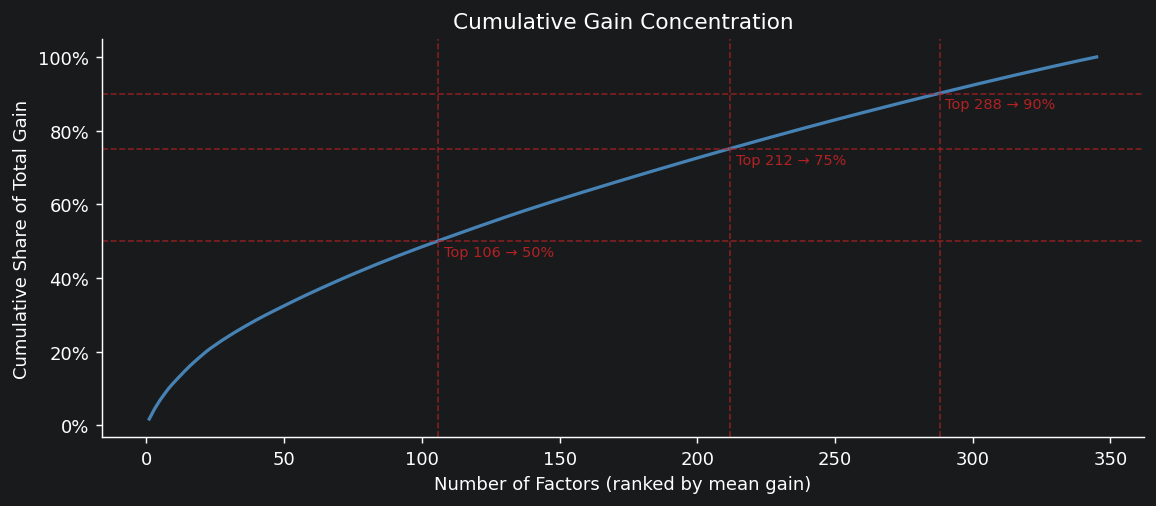

In [90]:
sorted_gain = summary.sort_values("gain_mean", ascending=False)["gain_mean"].values
cum_share = np.cumsum(sorted_gain) / sorted_gain.sum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cum_share) + 1), cum_share, linewidth=1.8, color="steelblue")
for threshold in [0.5, 0.75, 0.90]:
    k = int(np.searchsorted(cum_share, threshold)) + 1
    ax.axvline(k, linestyle="--", linewidth=0.9, color="firebrick", alpha=0.7)
    ax.axhline(threshold, linestyle="--", linewidth=0.9, color="firebrick", alpha=0.7)
    ax.annotate(f"Top {k} → {threshold:.0%}", xy=(k, threshold),
                xytext=(k + 2, threshold - 0.04), fontsize=8, color="firebrick")
ax.set_xlabel("Number of Factors (ranked by mean gain)")
ax.set_ylabel("Cumulative Share of Total Gain")
ax.set_title("Cumulative Gain Concentration")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig(IMP_DIR / "cumulative_gain.png", bbox_inches="tight")
plt.show()

## 9 · Export Summary Tables

In [91]:
# full resolved importance (all years, real column names)
all_resolved = pd.concat(
    [_resolve_features(
        pd.read_csv(f),
        pickle.load(open(model_files[int(f.stem.split('_')[1])], 'rb'))["feature_names"]
        if int(f.stem.split('_')[1]) in model_files else []
    )
     for f in imp_files],
    ignore_index=True
)
all_resolved.to_csv(IMP_DIR / "feature_importance_all_resolved.csv", index=False)

# time-averaged summary with category
summary_out = summary[["feature", "category", "gain_mean", "gain_std",
                         "gain_norm_mean", "weight_mean", "cover_mean",
                         "pct_years_active"]].copy()
summary_out = summary_out.merge(rank_df[["feature", "mean_rank", "std_rank"]], on="feature", how="left")
summary_out.to_csv(IMP_DIR / "feature_importance_summary_resolved.csv", index=False)

print("Saved:")
print(f"  {IMP_DIR}/feature_importance_all_resolved.csv  ({len(all_resolved):,} rows)")
print(f"  {IMP_DIR}/feature_importance_summary_resolved.csv  ({len(summary_out)} factors)")
display(summary_out.head(20))

Saved:
  ../data/backtest/xgboost_ab/feature_importance/feature_importance_all_resolved.csv  (11,748 rows)
  ../data/backtest/xgboost_ab/feature_importance/feature_importance_summary_resolved.csv  (345 factors)


,feature,category,gain_mean,gain_std,gain_norm_mean,weight_mean,cover_mean,pct_years_active,mean_rank,std_rank
0,rmax5_21d,Other,14.300759,7.488213,0.016530,51.471264,289811.458962,0.725,5.551724,6.395234
1,ebit_mev,Value,12.220834,9.259628,0.016967,8.950000,186361.960449,1.000,14.575000,25.979171
2,ebitda_mev,Quality,11.878275,6.800768,0.015108,9.608333,178975.079558,1.000,12.175000,38.295000
3,ocf_me,Value,10.253549,9.210219,0.012471,9.000000,199404.444084,1.000,17.100000,22.384518
4,fcf_ppen,Other,10.144097,13.032752,0.012658,10.241667,154225.660482,1.000,27.650000,30.382645
5,rmax1_21d,Other,8.799600,5.633950,0.010119,13.494253,148098.976742,0.725,15.724138,13.737063
6,ebit_me,Other,8.743470,4.869535,0.012649,18.025000,194482.126497,1.000,11.300000,7.335198
7,ocf_mev,Value,8.294988,5.799081,0.010414,8.108333,135918.853442,1.000,23.625000,32.966718
8,mispricing_perf,Other,7.564133,3.678966,0.009808,19.025000,168390.608382,1.000,13.425000,9.922488
9,prc_low,Momentum,6.986389,4.649345,0.010625,18.241667,182193.472282,1.000,39.025000,42.554031
